<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_0_Classification_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Predicting Credit Default: Part 1
## Logistic Regression Foundations

**Author:** Brad Sheese

---

### Learning Objectives
In this first notebook, we will establish the foundations of classification by exploring:
1. How to identify and visualize class imbalance.
2. Why accuracy is often a trap in classification.
3. How to train a logistic regression model and interpret its coefficients.
4. The difference between hard predictions (labels) and soft predictions (probabilities).

## Why Not Linear Regression?

Up to this point, we have used linear regression to predict continuous numbers (like House Prices). However, many real-world problems ask a binary question: *Will this customer default on their loan?* (Yes/No), *Is this email spam?* (Yes/No), *Is this tumor malignant?* (Yes/No).

If we try to force a linear regression line to solve these problems, we run into the "Square Peg in a Round Hole" problem. Linear lines are **unbounded**—they extend to infinity. But probabilities are **bounded** between 0 and 1. A linear model might predict a -20% chance of default or a 140% chance of being spam, both of which are mathematically nonsensical.

### The Sigmoid (Logistic) Function

To solve this, we use the Sigmoid function. Think of it as a "soft switch." Instead of a straight line, it creates an S-curve that squashes any input value into a range between 0 and 1.

$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X_1 + \dots)}}$$

- $P(Y=1)$ is the predicted probability that the observation belongs to the positive class (e.g., "Default").
- $\beta_0$ is the intercept, representing the base log-odds.
- $\beta_1, \beta_2, \dots$ are the coefficients that determine the influence of each feature.
- $e$ is the base of the natural logarithm.

The magic of the sigmoid function is that it "squashes" any real-valued number into the range $(0, 1)$. If the linear part produces a large positive value, the sigmoid returns a probability close to 1. If it produces a large negative value, it returns a probability close to 0. This transformation bridges the gap between linear regression and probability.

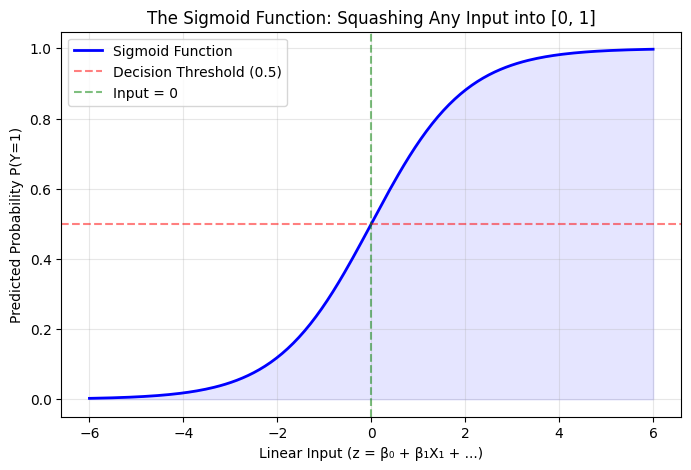

Key observations:
  Input z =  0  →  Probability = 0.500
  Input z =  2  →  Probability = 0.881
  Input z = -2  →  Probability = 0.119
  Input z =  5  →  Probability = 0.9933
  Input z = -5  →  Probability = 0.0067


In [1]:
# Visualize the Sigmoid Function
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-6, 6, 200)
p = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, p, 'b-', linewidth=2, label='Sigmoid Function')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision Threshold (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5, label='Input = 0')
plt.fill_between(z, p, alpha=0.1, color='b')
plt.xlabel('Linear Input (z = β₀ + β₁X₁ + ...)')
plt.ylabel('Predicted Probability P(Y=1)')
plt.title('The Sigmoid Function: Squashing Any Input into [0, 1]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Key observations:")
print(f"  Input z =  0  →  Probability = {sigmoid(0):.3f}")
print(f"  Input z =  2  →  Probability = {sigmoid(2):.3f}")
print(f"  Input z = -2  →  Probability = {sigmoid(-2):.3f}")
print(f"  Input z =  5  →  Probability = {sigmoid(5):.4f}")
print(f"  Input z = -5  →  Probability = {sigmoid(-5):.4f}")

Notice how the curve flattens out at the extremes. Even if the linear input goes to +100 or -100, the probability stays safely between 0 and 1. This is what makes logistic regression suitable for classification.

## Section 1: Load and Examine the Data

We will be using the South German Credit dataset. Our goal is to predict whether a loan applicant is a "good" or "bad" credit risk based on features like their checking account status, credit history, and employment duration.

**Data Source:** https://archive.ics.uci.edu/dataset/522/south+german+credit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load the Credit Card Default dataset from OpenML
from sklearn.datasets import fetch_openml

print('Loading dataset...')
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame

print(f'Dataset shape: {df.shape}')
df.head()

Loading dataset...
Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Examine the Dataframe

Notice the mix of numerical and categorical columns. Just like in our Regression notebooks, we will need to handle these differently.

Look closely at the `class` column. This is our target variable. It contains labels 'good' and 'bad'.

## Section 2: The Accuracy Paradox and Class Imbalance

One of the most important concepts in classification is **class distribution**. In many real-world scenarios (like fraud or rare diseases), the classes are not 50/50.

If 99% of people do not have a rare disease, a "dumb" model that simply predicts "No Disease" for every single person will be 99% accurate. However, it is a completely useless model because it fails to catch the very thing we care about (the 1%). This is known as the **accuracy paradox**.

Let's see how imbalanced our credit dataset is.

Target variable distribution:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


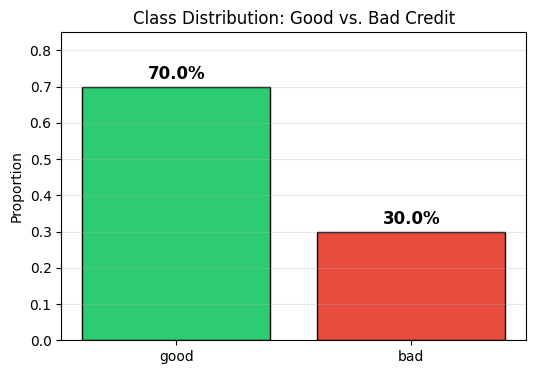


Naive baseline accuracy (always predict 'Good'): 70.0%
Any useful model must significantly exceed this baseline.


In [3]:
# Check target variable distribution
class_counts = df['class'].value_counts(normalize=True)
print('Target variable distribution:')
print(class_counts)

# Visualize
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylabel('Proportion')
plt.title('Class Distribution: Good vs. Bad Credit')
plt.ylim(0, 0.85)
plt.grid(axis='y', alpha=0.3)
plt.show()

baseline = (df['class'] == 'good').mean()
print(f"\nNaive baseline accuracy (always predict 'Good'): {baseline:.1%}")
print("Any useful model must significantly exceed this baseline.")

### Understanding the Baseline

70% of our samples are 'Good'. This means that if we built a model that did nothing but guess 'Good' for every customer, we would achieve 70% accuracy.

As you move through these notebooks, always remember: **If your model's accuracy isn't significantly better than the majority class percentage, your model hasn't learned anything useful.**

## Section 3: Preparing the Data for Logistic Regression

To train our model, we must perform several cleaning steps:

1. **Binary encoding:** Convert our target ('good'/'bad') into numbers (0 and 1). Logistic regression requires numeric targets.
2. **One-hot encoding:** Convert categorical text columns (like 'employment') into multiple binary numeric columns. The model can't process text.
3. **Stratified split:** Ensure that our training and testing sets have the same 70/30 ratio of 'good' vs 'bad' cases. Without stratification, a random split might accidentally give us a test set that's 90% 'good', making evaluation misleading.
4. **Feature scaling:** Logistic regression uses gradient descent, which converges much faster if all features are on the same scale (mean=0, std=1). Without scaling, features with large ranges (like credit_amount) would dominate the optimization.

In [4]:
# 1. Convert target to binary: good = 0 (Normal), bad = 1 (Event of interest/Default)
y = (df['class'] == 'bad').astype(int)
X = df.drop(columns=['class'])

# 2. Identify and encode categorical features
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 3. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# 4. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Original features: {X.shape[1]}')
print(f'Encoded features: {X_encoded.shape[1]}')
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set class ratio: {y_test.mean():.1%} bad, {(1-y_test.mean()):.1%} good')

Original features: 20
Encoded features: 48
Training set size: 700
Test set class ratio: 30.0% bad, 70.0% good


## Section 4: Training the Logistic Regression Model

### How the Model Learns: Maximum Likelihood Estimation (MLE)

Linear regression finds the line that minimizes "Squared Error." Logistic regression is different. It uses **Maximum Likelihood Estimation**.

The algorithm iterates through different coefficients (weights) until it finds the ones that make the labels we actually observed in the data the "most likely" outcome.

**Concrete example:** Imagine we observe 3 defaults out of 10 applicants. The model adjusts its weights so that the *predicted* probability of default for those 3 people is as high as possible (close to 1.0), while the predicted probability for the 7 non-defaulters is as low as possible (close to 0.0). The "likelihood" is the product of all these individual probabilities — and the model finds the coefficients that maximize this product.

### Class Weighting

Because we have an imbalanced dataset (70/30), we will use the parameter `class_weight='balanced'`. This tells the model to "pay more attention" to the minority class (the defaults). Essentially, it penalizes the model more heavily when it gets a 'Bad' credit prediction wrong than when it gets a 'Good' credit prediction wrong.

In [5]:
# Instantiate and train the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Compensate for imbalance
)
model.fit(X_train_scaled, y_train)

print('Model training complete.')

Model training complete.


## Section 5: Interpreting the Model Internals

Just like in multiple linear regression, we can look at the coefficients ($\beta$ values) to see which features are driving the model's decisions.

However, there is a catch: these coefficients are in the unit of **log-odds**.
- A **positive coefficient** means that as this feature increases, the probability of the event (Default) increases.
- A **negative coefficient** means that as this feature increases, the probability of Default decreases.
- The **magnitude** (absolute value) tells you the strength of that relationship.

### From Log-Odds to Odds Ratios

Log-odds are hard to interpret directly. We can convert them to **odds ratios** by taking $e^{\beta}$ (np.exp). An odds ratio of 1.65 means the odds of default increase by 65% for each standard deviation increase in that feature.

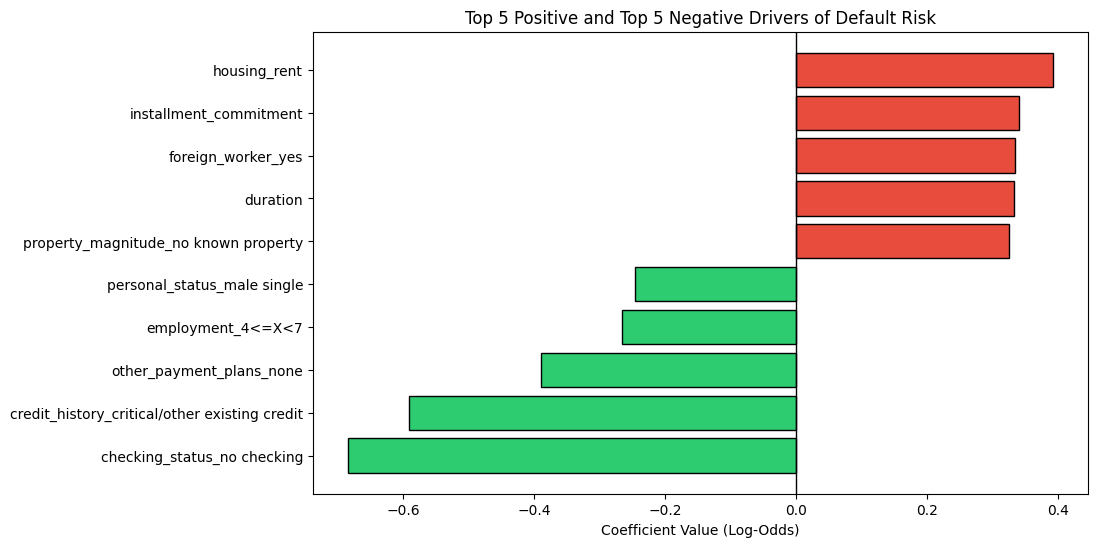


Top 3 Default Risk Drivers (with Odds Ratios):
  housing_rent                   Log-Odds: +0.392  |  Odds Ratio: 1.48
  installment_commitment         Log-Odds: +0.341  |  Odds Ratio: 1.41
  foreign_worker_yes             Log-Odds: +0.334  |  Odds Ratio: 1.40


In [6]:
# Extract coefficients
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient (Log-Odds)': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Coefficient (Log-Odds)', ascending=False)

# Visualize the top drivers of default
plt.figure(figsize=(10, 6))
top_and_bottom = pd.concat([coef_df.head(5), coef_df.tail(5)])
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_and_bottom['Coefficient (Log-Odds)']]

plt.barh(top_and_bottom['Feature'], top_and_bottom['Coefficient (Log-Odds)'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Coefficient Value (Log-Odds)')
plt.title('Top 5 Positive and Top 5 Negative Drivers of Default Risk')
plt.gca().invert_yaxis()
plt.show()

# Show top 3 with odds ratios
print("\nTop 3 Default Risk Drivers (with Odds Ratios):")
for _, row in coef_df.head(3).iterrows():
    print(f"  {row['Feature']:<30} Log-Odds: {row['Coefficient (Log-Odds)']:+.3f}  |  Odds Ratio: {row['Odds Ratio']:.2f}")

### Interpreting the Results

Look at the features with the largest positive coefficients (red bars). These are the factors that most strongly suggest a person will default. Conversely, the largest negative coefficients (green bars) are the strongest indicators of a "Good" credit risk.

**Important:** Because we scaled all features to mean=0 and std=1, these coefficients are **directly comparable in magnitude**. A larger absolute value means a stronger effect on the prediction, regardless of the original feature's units.

For example, if `duration` has a coefficient of +0.5, the odds ratio is e^0.5 ≈ 1.65. This means each standard deviation increase in loan duration increases the odds of default by 65%.

## Section 6: Probabilities and the Decision Threshold

When we ask a model to `.predict()`, it gives us a hard prediction (a 0 or a 1). But inside the model, it actually calculates a soft prediction (a probability between 0 and 1).

By default, sklearn uses a threshold of 0.5:
- If $P(Default) \ge 0.5$, predict 1.
- If $P(Default) < 0.5$, predict 0.

Let's visualize how these probabilities are distributed for our test set.

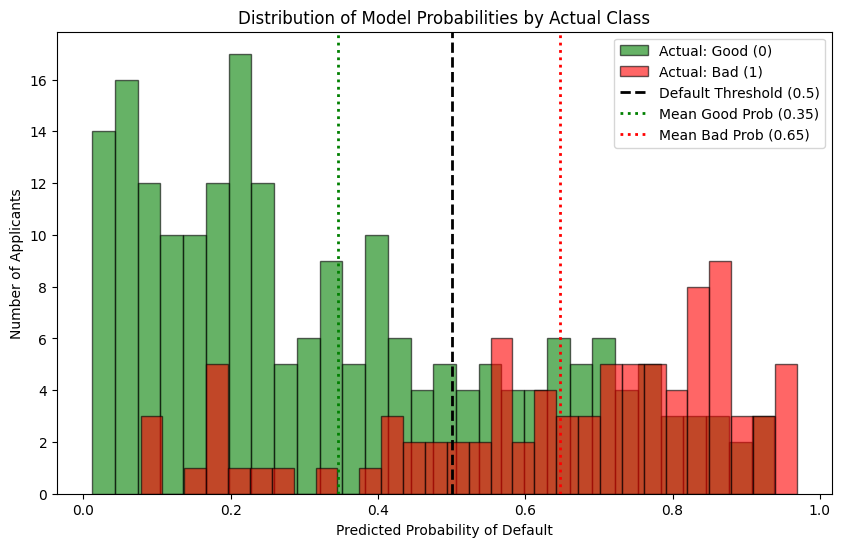


Overlap Analysis:
  23.3% of actual defaulters scored below 0.5 (missed cases / false negatives)
  28.1% of good customers scored above 0.5 (false alarms / false positives)


In [7]:
# Get probabilities for the positive class (Default)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

fig, ax = plt.subplots(figsize=(10, 6))

# Plot overlapping histograms by actual class
ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: Good (0)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: Bad (1)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_good = y_proba[y_test==0].mean()
mean_bad = y_proba[y_test==1].mean()
ax.axvline(x=mean_good, color='green', linestyle=':', linewidth=2, label=f'Mean Good Prob ({mean_good:.2f})')
ax.axvline(x=mean_bad, color='red', linestyle=':', linewidth=2, label=f'Mean Bad Prob ({mean_bad:.2f})')

ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Number of Applicants')
ax.set_title('Distribution of Model Probabilities by Actual Class')
ax.legend()
plt.show()

print(f"\nOverlap Analysis:")
print(f"  {fn_rate:.1f}% of actual defaulters scored below 0.5 (missed cases / false negatives)")
print(f"  {fp_rate:.1f}% of good customers scored above 0.5 (false alarms / false positives)")

### Reading the Probability Distribution

- The **green distribution** (actual good customers) is shifted left — the model generally assigns them low default probabilities.
- The **red distribution** (actual defaulters) is shifted right — the model generally assigns them higher default probabilities.
- The **dotted lines** show the mean probability for each class. The further apart these are, the better the model is at separating the two groups.
- The **overlap** around the 0.5 threshold is where the model is uncertain. The percentages printed above quantify this: {fn_rate:.1f}% of actual defaulters were missed, and {fp_rate:.1f}% of good customers were falsely flagged.

In Notebook 3, we will learn how to move that 0.5 line to better suit our business needs.

## Section 7: Basic Model Evaluation

Before we dive into the confusion matrix in Part 2, let's check the model's basic accuracy and compare it to our naive baseline.

In [8]:
accuracy = model.score(X_test_scaled, y_test)
baseline = (y_test == 0).mean()

print(f"Model Accuracy:      {accuracy:.1%}")
print(f"Naive Baseline:      {baseline:.1%}")
print(f"Improvement:         {(accuracy - baseline):.1%} above baseline")

if accuracy > baseline:
    print(f"\nOur model is {(accuracy/baseline - 1)*100:.0f}% better than always guessing 'Good'.")
else:
    print("\nWarning: The model is not beating the naive baseline.")

Model Accuracy:      73.3%
Naive Baseline:      70.0%
Improvement:         3.3% above baseline

Our model is 5% better than always guessing 'Good'.


## Conclusion

In this notebook, we've moved from the world of continuous prediction to the world of classification. Key takeaways:

1. **The sigmoid function** squashes any input into a probability between 0 and 1, making it suitable for binary classification.
2. **Class imbalance** makes accuracy a potentially deceptive metric — always compare against the naive baseline.
3. **Coefficients are in log-odds units** — positive coefficients increase default risk, negative coefficients decrease it. Converting to odds ratios ($e^{\beta}$) makes them more interpretable.
4. **Probabilities vs. hard predictions** — the model calculates a probability for every applicant; the 0.5 threshold converts this to a yes/no decision. The overlap between the two class distributions shows where the model is uncertain.

In the next notebook, we will dive deeper into model evaluation using the **confusion matrix** to see exactly where our model is making mistakes, and learn about precision, recall, and the f1-score.